In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('customer_behaviour.csv')

In [5]:
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5045,913,24,Male,Hoodie,Clothing,56.0,Arkansas,M,Green,Winter,3.4,Yes,Next Day Air,Yes,32.0,Bank Transfer,Monthly
5046,3466,19,Female,Backpack,Accessories,53.0,Iowa,M,Gold,Spring,3.4,No,Standard,No,31.0,Debit Card,Weekly
5047,3572,70,Female,Skirt,Clothing,27.0,North Dakota,M,White,Summer,3.2,No,Standard,No,15.0,Bank Transfer,Every 3 Months
5048,3195,43,Female,Sneakers,Footwear,52.0,Maryland,L,Gold,Summer,4.6,No,Standard,No,10.0,Credit Card,Bi-Weekly


In [6]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


In [7]:
df.shape

(5050, 17)

In [8]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,5050.000000,5050.000000,4494.000000,4449.000000,4502.000000
mean,2519.570891,44.150495,144.765236,3.668195,25.221901
std,1470.402964,15.282328,275.590101,0.865357,14.521635
min,1.000000,18.000000,10.120000,1.000000,0.000000
25%,1252.250000,31.000000,41.000000,3.000000,13.000000
50%,2499.500000,44.000000,65.000000,3.700000,25.000000
75%,3740.750000,57.000000,89.000000,4.400000,38.000000
max,5099.000000,70.000000,1499.760000,5.000000,50.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5050 non-null   int64  
 1   Age                     5050 non-null   int64  
 2   Gender                  5050 non-null   object 
 3   Item Purchased          5050 non-null   object 
 4   Category                5050 non-null   object 
 5   Purchase Amount (USD)   4494 non-null   float64
 6   Location                5050 non-null   object 
 7   Size                    4680 non-null   object 
 8   Color                   5050 non-null   object 
 9   Season                  5050 non-null   object 
 10  Review Rating           4449 non-null   float64
 11  Subscription Status     5050 non-null   object 
 12  Shipping Type           5050 non-null   object 
 13  Discount Applied        5050 non-null   object 
 14  Previous Purchases      4502 non-null   

In [10]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                      370
Color                       0
Season                      0
Review Rating             601
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases        548
Payment Method              0
Frequency of Purchases      0
dtype: int64

#DATA CLEANING

In [12]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


In [13]:
#get the distinct values in item purchased
df['Item Purchased'].unique()

array(['T-shirt', 'Sunglasses', 'Shirt', 'Gloves', 'Jewelry', 'Shorts',
       'Hat', 'Handbag', 'Shoes', 'Coat', 'Laptop', 'Hoodie', 'Phone',
       'Jacket', 'Pants', 'Backpack', 'Socks', 'Jeans', 'Bag', 'Belt',
       'Watch', 'Headphones', 'Blouse', 'Sandals', 'Skirt', 'Sweater',
       'Scarf', 'Sneakers', 'Boots', 'Dress'], dtype=object)

In [14]:
df['Category'].unique()

array(['Clothing', 'Accessories', 'Outerwear', 'Electronics', 'Footwear'],
      dtype=object)

In [15]:
#to display the whole records
pd.set_option('display.max_colwidth',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [16]:
df.groupby('Category')['Item Purchased'].unique()

Category
Accessories               [Sunglasses, Gloves, Jewelry, Hat, Handbag, Phone, Backpack, Belt, Bag, Headphones, Scarf, Watch, Shirt, Shoes, Laptop]
Clothing       [T-shirt, Shirt, Shorts, Shoes, Hoodie, Phone, Pants, Socks, Jeans, Bag, Blouse, Skirt, Sweater, Watch, Laptop, Dress, Headphones]
Electronics                                                                                 [Laptop, Phone, Watch, Bag, Shoes, Shirt, Headphones]
Footwear                                                                                                        [Shoes, Sandals, Sneakers, Boots]
Outerwear                                                                                                                          [Coat, Jacket]
Name: Item Purchased, dtype: object

In [17]:
#since one product is mapped to many categories we would correct the mapping
category_mapping = {
    'Sunglasses': 'Accessories',
    'Gloves': 'Accessories',
    'Jewelry': 'Accessories',
    'Hat': 'Accessories',
    'Handbag': 'Accessories',
    'Backpack': 'Accessories',
    'Belt': 'Accessories',
    'Scarf': 'Accessories',
    'Bag': 'Accessories',

    'T-shirt': 'Clothing',
    'Shirt': 'Clothing',
    'Shorts': 'Clothing',
    'Hoodie': 'Clothing',
    'Pants': 'Clothing',
    'Socks': 'Clothing',
    'Jeans': 'Clothing',
    'Blouse': 'Clothing',
    'Skirt': 'Clothing',
    'Sweater': 'Clothing',
    'Dress': 'Clothing',

    'Laptop': 'Electronics',
    'Phone': 'Electronics',
    'Watch': 'Electronics',
    'Headphones': 'Electronics',

    'Shoes': 'Footwear',
    'Sandals': 'Footwear',
    'Sneakers': 'Footwear',
    'Boots': 'Footwear',

    'Coat': 'Outerwear',
    'Jacket': 'Outerwear'
}

In [18]:
df['Category']= df['Item Purchased'].map(category_mapping)

In [19]:
df.head()


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


In [20]:
df.groupby('Category')['Item Purchased'].unique()

Category
Accessories                 [Sunglasses, Gloves, Jewelry, Hat, Handbag, Backpack, Bag, Belt, Scarf]
Clothing       [T-shirt, Shirt, Shorts, Hoodie, Pants, Socks, Jeans, Blouse, Skirt, Sweater, Dress]
Electronics                                                      [Laptop, Phone, Watch, Headphones]
Footwear                                                          [Shoes, Sandals, Sneakers, Boots]
Outerwear                                                                            [Coat, Jacket]
Name: Item Purchased, dtype: object

#Treating null values

In [22]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                      370
Color                       0
Season                      0
Review Rating             601
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases        548
Payment Method              0
Frequency of Purchases      0
dtype: int64

In [23]:
df['Size'].unique()

array(['XL', 'M', 'L', 'S', nan], dtype=object)

In [24]:
df.groupby('Category')['Size'].unique()

Category
Accessories    [M, L, S, XL, nan]
Clothing       [XL, M, S, L, nan]
Electronics    [nan, L, S, M, XL]
Footwear       [M, L, S, nan, XL]
Outerwear           [XL, L, S, M]
Name: Size, dtype: object

In [25]:
df.groupby('Item Purchased')['Size'].unique()

Item Purchased
Backpack           [M, S, L, XL]
Bag           [M, L, nan, XL, S]
Belt               [M, S, XL, L]
Blouse             [M, L, S, XL]
Boots              [L, M, XL, S]
Coat               [XL, M, S, L]
Dress              [XL, M, L, S]
Gloves             [L, M, S, XL]
Handbag            [S, XL, M, L]
Hat                [M, L, S, XL]
Headphones    [S, M, nan, L, XL]
Hoodie             [M, L, S, XL]
Jacket             [L, S, M, XL]
Jeans              [L, M, XL, S]
Jewelry            [L, XL, M, S]
Laptop        [nan, M, S, XL, L]
Pants              [L, M, XL, S]
Phone         [nan, L, S, M, XL]
Sandals            [M, S, L, XL]
Scarf              [M, L, S, XL]
Shirt         [M, XL, L, S, nan]
Shoes         [M, L, nan, XL, S]
Shorts             [S, M, L, XL]
Skirt              [S, L, M, XL]
Sneakers           [S, M, L, XL]
Socks              [M, XL, L, S]
Sunglasses         [M, L, S, XL]
Sweater            [M, S, L, XL]
T-shirt            [XL, M, S, L]
Watch         [nan, M, L, XL

In [26]:
#replacing the null values in electronics using loc
df.loc[df['Category']=='Electronics','Size'] = "Not Applicable"

In [27]:
df.groupby('Category')['Size'].unique()

Category
Accessories    [M, L, S, XL, nan]
Clothing       [XL, M, S, L, nan]
Electronics      [Not Applicable]
Footwear       [M, L, S, nan, XL]
Outerwear           [XL, L, S, M]
Name: Size, dtype: object

In [28]:
#replacing the null values in accessories using loc
df.loc[df['Category']=='Accessories','Size'] = "Free size"

In [29]:
df.groupby('Category')['Size'].unique()

Category
Accessories           [Free size]
Clothing       [XL, M, S, L, nan]
Electronics      [Not Applicable]
Footwear       [M, L, S, nan, XL]
Outerwear           [XL, L, S, M]
Name: Size, dtype: object

In [30]:
#replacing the null values in footwear using loc
df.loc[df['Category']=='Footwear','Size'] = "Not Available"

In [31]:
df.groupby('Category')['Size'].unique()

Category
Accessories           [Free size]
Clothing       [XL, M, S, L, nan]
Electronics      [Not Applicable]
Footwear          [Not Available]
Outerwear           [XL, L, S, M]
Name: Size, dtype: object

In [32]:
#replacing the null values in clothing using loc
df.loc[
    (df['Category'] == 'Clothing') & (df['Size'].isnull()),
    'Size'
] = df[df['Category'] == 'Clothing']['Size'].mode()[0]

In [33]:
df.groupby('Category')['Size'].unique()

Category
Accessories         [Free size]
Clothing          [XL, M, S, L]
Electronics    [Not Applicable]
Footwear        [Not Available]
Outerwear         [XL, L, S, M]
Name: Size, dtype: object

Cleaning Review rating

In [35]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,Free size,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,Free size,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,Free size,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


In [36]:
df['Review Rating'].mean()

3.668195100022477

In [37]:
df['Review Rating'].median()

3.7

In [38]:
df['Review Rating'].mode()

0    4.0
Name: Review Rating, dtype: float64

In [39]:
df.groupby('Item Purchased')['Review Rating'].mean()

Item Purchased
Backpack      3.758333
Bag           3.168539
Belt          3.762963
Blouse        3.677647
Boots         3.813194
Coat          3.721875
Dress         3.750000
Gloves        3.862774
Handbag       3.771975
Hat           3.796753
Headphones    3.075949
Hoodie        3.716779
Jacket        3.761446
Jeans         3.651969
Jewelry       3.761850
Laptop        3.191176
Pants         3.720833
Phone         2.939024
Sandals       3.837037
Scarf         3.702564
Shirt         3.427273
Shoes         3.546154
Shorts        3.722981
Skirt         3.779747
Sneakers      3.757931
Socks         3.755063
Sunglasses    3.745679
Sweater       3.768712
T-shirt       3.790541
Watch         3.100000
Name: Review Rating, dtype: float64

In [40]:
#replacing null values of review ratings by the mean of each item purchased
df['Review Rating']=df['Review Rating'].fillna(df.groupby('Item Purchased')['Review Rating'].transform('mean'))

In [41]:
df['Review Rating']=df['Review Rating'].round(2)

Cleaning previous purchases


In [43]:
df['Previous Purchases']=df['Previous Purchases'].fillna(0)

In [44]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases          0
Payment Method              0
Frequency of Purchases      0
dtype: int64

In [45]:
#df.drop(columns='size', inplace=True)

In [46]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases          0
Payment Method              0
Frequency of Purchases      0
dtype: int64

In [47]:
df[df['Size'].isnull()]['Category'].value_counts()

Series([], Name: count, dtype: int64)

In [48]:
df.loc[
    (df['Category'] == 'Accessories') & (df['Size'].isnull()),
    'Size'
] = 'Free Size'

In [49]:
df.groupby("Item Purchased")['Purchase Amount (USD)'].mean()

Item Purchased
Backpack       60.111111
Bag           735.773625
Belt           59.993902
Blouse         60.802326
Boots          62.616438
Coat           57.851852
Dress          62.168675
Gloves         60.550000
Handbag        57.987261
Hat            60.787097
Headphones    831.344565
Hoodie         58.059603
Jacket         56.777108
Jeans          60.456693
Jewelry        59.011494
Laptop        805.502027
Pants          59.005848
Phone         734.477349
Sandals        57.527607
Scarf          61.157233
Shirt         279.935608
Shoes         276.343790
Shorts         60.073620
Skirt          59.723270
Sneakers       59.551724
Socks          58.188679
Sunglasses     59.975610
Sweater        57.638554
T-shirt        63.093333
Watch         685.231471
Name: Purchase Amount (USD), dtype: float64

In [50]:
df.groupby("Item Purchased")['Purchase Amount (USD)'].median()

Item Purchased
Backpack       59.000
Bag           766.850
Belt           59.500
Blouse         61.500
Boots          65.500
Coat           55.000
Dress          63.500
Gloves         61.500
Handbag        57.000
Hat            62.000
Headphones    854.555
Hoodie         57.000
Jacket         55.000
Jeans          61.000
Jewelry        57.000
Laptop        826.425
Pants          59.000
Phone         736.010
Sandals        58.000
Scarf          64.000
Shirt          78.000
Shoes          78.000
Shorts         61.000
Skirt          61.000
Sneakers       59.000
Socks          55.000
Sunglasses     61.500
Sweater        56.000
T-shirt        64.500
Watch         641.485
Name: Purchase Amount (USD), dtype: float64

In [51]:
df['Purchase Amount (USD)']=df['Purchase Amount (USD)'].fillna(df.groupby('Item Purchased')['Purchase Amount (USD)'].transform('mean'))

In [52]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [53]:
#duplicates check
df.duplicated().sum()

50

In [54]:
df[df.duplicated()]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
886,2834,43,Female,Jeans,Clothing,56.0,Arkansas,M,Teal,Fall,3.30,No,Free Shipping,No,19.0,Cash,Monthly
1402,1621,25,Male,Hat,Accessories,47.0,Virginia,Free size,Charcoal,Winter,3.10,No,2-Day Shipping,Yes,27.0,PayPal,Every 3 Months
1509,974,60,Male,Jacket,Outerwear,75.0,Colorado,M,Teal,Fall,3.50,Yes,2-Day Shipping,Yes,30.0,Bank Transfer,Quarterly
1600,2135,55,Male,Sandals,Footwear,41.0,Virginia,Not Available,Maroon,Winter,2.90,No,Standard,No,35.0,Credit Card,Fortnightly
1665,1846,51,Male,Sandals,Footwear,78.0,Delaware,Not Available,Orange,Winter,2.80,No,2-Day Shipping,No,39.0,Bank Transfer,Quarterly
1797,3639,40,Female,Backpack,Accessories,20.0,Kansas,Free size,Olive,Spring,4.60,No,Express,No,50.0,PayPal,Bi-Weekly
1870,3456,49,Female,T-shirt,Clothing,89.0,Ohio,M,Orange,Fall,4.70,No,Standard,No,13.0,Venmo,Annually
2033,1812,42,Male,Belt,Accessories,77.0,Wisconsin,Free size,Blue,Summer,3.60,No,Standard,No,33.0,Bank Transfer,Annually
2113,3040,59,Female,Blouse,Clothing,48.0,Alabama,L,Blue,Spring,3.20,No,Next Day Air,No,31.0,PayPal,Bi-Weekly
2226,1371,27,Male,Scarf,Accessories,67.0,Montana,Free size,Peach,Summer,3.70,No,2-Day Shipping,Yes,41.0,Bank Transfer,Every 3 Months


#deleting duplicates

In [56]:
len(df)

5050

In [57]:
df = df.drop_duplicates(subset = ['Customer ID'], keep = 'first')

In [58]:
df.duplicated().sum()

0

Rename the Headers

In [60]:
df.columns = df.columns.str.replace(" ", "_")

In [61]:
df.head()

,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_Amount_(USD),Location,Size,Color,Season,Review_Rating,Subscription_Status,Shipping_Type,Discount_Applied,Previous_Purchases,Payment_Method,Frequency_of_Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,Free size,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,Free size,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,Free size,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


In [62]:
df.columns = df.columns.str.lower()

In [63]:
#renaming the purchase_amount_(usd) column
df = df.rename(columns={"purchase_amount_(usd)": "purchase_amount"})

In [64]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,Free size,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,Free size,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,Free size,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


SQL SERVER CONNECCTION

In [66]:
!pip install mysql-connector-python sqlalchemy pandas
import mysql.connector
from sqlalchemy import create_engine
import pandas as pd


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


ModuleNotFoundError: No module named 'mysql'

In [71]:
from sqlalchemy import create_engine

engine = create_engine(
    "mysql+mysqlconnector://root:@localhost/customer_analysis"
)

print("Connection Successful!")

ModuleNotFoundError: No module named 'mysql'

In [69]:
table_name = "customers"

df.to_sql(
    table_name,
    con=engine,
    if_exists="replace",
    index=False
)

print("Data successfully loaded into MySQL!")

NameError: name 'engine' is not defined

In [ ]:
print(df.columns)

In [ ]:
df.to_sql(
    "customers",
    con=engine,
    if_exists="replace",
    index=False
)

print("Updated table uploaded successfully!")

In [73]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,Free size,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,Free size,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,Free size,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


In [75]:
df.to_csv("customers.csv", index=False)

In [77]:
import os
os.getcwd()

'/Users/gulkapoor/DataAnalysisProjects'

In [79]:
os.listdir()

['customer_subscription_churn_usage_patterns.csv',
 'customers.csv',
 '02_Job_Description_Scraping.ipynb.ipynb',
 '.DS_Store',
 'Saas_churn_analysis.ipynb',
 'customer_behaviour.csv',
 'Diwali Sales Analysis Python.ipynb',
 'Scrapped_data.ipynb',
 '3_PersonalFinance',
 'all_jobs.csv',
 'Diwali Sales Data.csv',
 'README.md',
 'download_help.png',
 '2_SalesInsightsTableau',
 'Data-Analytics-Projects',
 '.gitignore',
 '4_HRAnalytics',
 'customer behaviour analysis.ipynb',
 'combined_jobs.csv',
 'Data_Analytics_Job_Market_Analysis.ipynb',
 '.ipynb_checkpoints',
 '1_SalesInsights',
 '.git',
 'jobs_data.csv',
 'marketing_campaign.csv',
 '5_CricketT20Analytics']

In [ ]:
df.head()

Machine Learning: Subscription Status Prediction

Business Problem:
The objective is to predict whether a customer will subscribe based on their purchasing behavior, demographics, and shopping preferences. This can help businesses target potential subscribers and improve customer retention strategies.

In [81]:
# Checking the distribution of the target variable

df['subscription_status'].value_counts()

subscription_status
No     3421
Yes    1579
Name: count, dtype: int64

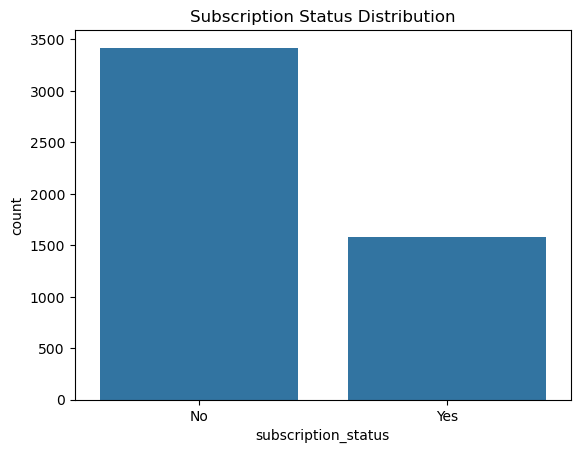

In [83]:
sns.countplot(
    data=df,
    x='subscription_status'

)

plt.title('Subscription Status Distribution')
plt.show()

In [85]:
df_ml = df.drop(columns=['customer_id'])

y = df_ml['subscription_status']
X = df_ml.drop('subscription_status', axis=1)

X.dtypes

age                         int64
gender                     object
item_purchased             object
category                   object
purchase_amount           float64
location                   object
size                       object
color                      object
season                     object
review_rating             float64
shipping_type              object
discount_applied           object
previous_purchases        float64
payment_method             object
frequency_of_purchases     object
dtype: object

Encoding - Since Ml Model don't understand categories we need to convert it into numbers

In [87]:
X.select_dtypes(include='object').columns

Index(['gender', 'item_purchased', 'category', 'location', 'size', 'color',
       'season', 'shipping_type', 'discount_applied', 'payment_method',
       'frequency_of_purchases'],
      dtype='object')

In [89]:
#converting Subscription status into numerical values
# Recreating target variable

y = df_ml['subscription_status']

# Encoding target variable

y = y.map({
    'No': 0,
    'Yes': 1
})

y.value_counts()

subscription_status
0    3421
1    1579
Name: count, dtype: int64

Feature Encoding

Machine learning algorithms cannot directly process categorical variables such as gender, shipping type, payment method, or product category. Therefore, One-Hot Encoding is applied to transform categorical features into numerical representations 

In [95]:
# Applying One-Hot Encoding to categorical features

X_encoded = pd.get_dummies(

    X,

    drop_first=True

)

X_encoded.head()

,age,purchase_amount,review_rating,previous_purchases,gender_Male,gender_Other,item_purchased_Bag,item_purchased_Belt,item_purchased_Blouse,item_purchased_Boots,item_purchased_Coat,item_purchased_Dress,item_purchased_Gloves,item_purchased_Handbag,item_purchased_Hat,item_purchased_Headphones,item_purchased_Hoodie,item_purchased_Jacket,item_purchased_Jeans,item_purchased_Jewelry,item_purchased_Laptop,item_purchased_Pants,item_purchased_Phone,item_purchased_Sandals,item_purchased_Scarf,item_purchased_Shirt,item_purchased_Shoes,item_purchased_Shorts,item_purchased_Skirt,item_purchased_Sneakers,item_purchased_Socks,item_purchased_Sunglasses,item_purchased_Sweater,item_purchased_T-shirt,item_purchased_Watch,category_Clothing,category_Electronics,category_Footwear,category_Outerwear,location_Alaska,location_Arizona,location_Arkansas,location_California,location_Chicago,location_Colorado,location_Connecticut,location_Delaware,location_Florida,location_Georgia,location_Hawaii,location_Houston,location_Idaho,location_Illinois,location_Indiana,location_Iowa,location_Kansas,location_Kentucky,location_Los Angeles,location_Louisiana,location_Maine,location_Maryland,location_Massachusetts,location_Michigan,location_Minnesota,location_Mississippi,location_Missouri,location_Montana,location_Nebraska,location_Nevada,location_New Hampshire,location_New Jersey,location_New Mexico,location_New York,location_North Carolina,location_North Dakota,location_Ohio,location_Oklahoma,location_Oregon,location_Pennsylvania,location_Phoenix,location_Rhode Island,location_South Carolina,location_South Dakota,location_Tennessee,location_Texas,location_Utah,location_Vermont,location_Virginia,location_Washington,location_West Virginia,location_Wisconsin,location_Wyoming,size_L,size_M,size_Not Applicable,size_Not Available,size_S,size_XL,color_Black,color_Blue,color_Brown,color_Charcoal,color_Cyan,color_Gold,color_Gray,color_Green,color_Indigo,color_Lavender,color_Magenta,color_Maroon,color_Olive,color_Orange,color_Peach,color_Pink,color_Purple,color_Red,color_Silver,color_Teal,color_Turquoise,color_Violet,color_White,color_Yellow,season_Fall,season_Spring,season_Summer,season_Winter,shipping_type_Express,shipping_type_Free Shipping,shipping_type_Next Day Air,shipping_type_Standard,shipping_type_Store Pickup,discount_applied_Yes,payment_method_Cash,payment_method_Credit Card,payment_method_Debit Card,payment_method_PayPal,payment_method_Venmo,frequency_of_purchases_Bi-Weekly,frequency_of_purchases_Every 3 Months,frequency_of_purchases_Fortnightly,frequency_of_purchases_Monthly,frequency_of_purchases_Quarterly,frequency_of_purchases_Weekly
0,22,68.0,3.2,36.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True
1,51,84.0,3.9,20.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False

In [97]:
print(X_encoded.shape)

(5000, 143)


Checking Missing Values After Encoding

Before training the model, it is important to ensure that the dataset does not contain missing values, as they may affect model performance and predictions.

In [99]:
# Checking for missing values

X_encoded.isnull().sum().sum()

0

Splitting Data into Training and Testing Sets

The dataset is divided into training and testing subsets to evaluate how well the model generalizes to unseen customer data.

The training set is used for learning patterns, while the testing set is used for performance evaluation.

In [101]:
from sklearn.model_selection import train_test_split

# Splitting dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (4000, 143)
Testing Features: (1000, 143)
Training Labels: (4000,)
Testing Labels: (1000,)


In [103]:
X_train.head()

,age,purchase_amount,review_rating,previous_purchases,gender_Male,gender_Other,item_purchased_Bag,item_purchased_Belt,item_purchased_Blouse,item_purchased_Boots,item_purchased_Coat,item_purchased_Dress,item_purchased_Gloves,item_purchased_Handbag,item_purchased_Hat,item_purchased_Headphones,item_purchased_Hoodie,item_purchased_Jacket,item_purchased_Jeans,item_purchased_Jewelry,item_purchased_Laptop,item_purchased_Pants,item_purchased_Phone,item_purchased_Sandals,item_purchased_Scarf,item_purchased_Shirt,item_purchased_Shoes,item_purchased_Shorts,item_purchased_Skirt,item_purchased_Sneakers,item_purchased_Socks,item_purchased_Sunglasses,item_purchased_Sweater,item_purchased_T-shirt,item_purchased_Watch,category_Clothing,category_Electronics,category_Footwear,category_Outerwear,location_Alaska,location_Arizona,location_Arkansas,location_California,location_Chicago,location_Colorado,location_Connecticut,location_Delaware,location_Florida,location_Georgia,location_Hawaii,location_Houston,location_Idaho,location_Illinois,location_Indiana,location_Iowa,location_Kansas,location_Kentucky,location_Los Angeles,location_Louisiana,location_Maine,location_Maryland,location_Massachusetts,location_Michigan,location_Minnesota,location_Mississippi,location_Missouri,location_Montana,location_Nebraska,location_Nevada,location_New Hampshire,location_New Jersey,location_New Mexico,location_New York,location_North Carolina,location_North Dakota,location_Ohio,location_Oklahoma,location_Oregon,location_Pennsylvania,location_Phoenix,location_Rhode Island,location_South Carolina,location_South Dakota,location_Tennessee,location_Texas,location_Utah,location_Vermont,location_Virginia,location_Washington,location_West Virginia,location_Wisconsin,location_Wyoming,size_L,size_M,size_Not Applicable,size_Not Available,size_S,size_XL,color_Black,color_Blue,color_Brown,color_Charcoal,color_Cyan,color_Gold,color_Gray,color_Green,color_Indigo,color_Lavender,color_Magenta,color_Maroon,color_Olive,color_Orange,color_Peach,color_Pink,color_Purple,color_Red,color_Silver,color_Teal,color_Turquoise,color_Violet,color_White,color_Yellow,season_Fall,season_Spring,season_Summer,season_Winter,shipping_type_Express,shipping_type_Free Shipping,shipping_type_Next Day Air,shipping_type_Standard,shipping_type_Store Pickup,discount_applied_Yes,payment_method_Cash,payment_method_Credit Card,payment_method_Debit Card,payment_method_PayPal,payment_method_Venmo,frequency_of_purchases_Bi-Weekly,frequency_of_purchases_Every 3 Months,frequency_of_purchases_Fortnightly,frequency_of_purchases_Monthly,frequency_of_purchases_Quarterly,frequency_of_purchases_Weekly
4263,64,86.000000,2.70,21.0,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False
4721,39,57.000000,3.70,48.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fals

Logistic Regression Model

Logistic Regression is used as a baseline classification algorithm to predict customer subscription status. The model estimates the probability that a customer belongs to the subscribed class based on demographic and purchasing behavior features.

In [105]:
from sklearn.linear_model import LogisticRegression

# Creating Logistic Regression model

log_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

# Training the model

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [107]:
y_pred = log_model.predict(X_test)

y_pred[:10]

array([0, 0, 1, 1, 1, 0, 0, 1, 0, 1])

In [109]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.734


In [111]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[519 148]
 [118 215]]


In [113]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.78      0.80       667
           1       0.59      0.65      0.62       333

    accuracy                           0.73      1000
   macro avg       0.70      0.71      0.71      1000
weighted avg       0.74      0.73      0.74      1000



Classification Report Interpretation

The Logistic Regression model achieved an overall accuracy of 73.4%.

The model performed strongly in identifying non-subscribed customers, achieving an F1-score of 0.80. For subscribed customers, the model achieved an F1-score of 0.62, indicating moderate capability in identifying potential subscribers.

The results suggest that customer purchasing behavior and demographic characteristics contain meaningful information for predicting subscription status.

In [115]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient
131,discount_applied_Yes,2.392654
4,gender_Male,1.298934
43,location_Chicago,0.938955
5,gender_Other,0.912761
6,item_purchased_Bag,0.911188
79,location_Phoenix,0.733126
50,location_Houston,0.594374
56,location_Kentucky,0.412849
68,location_Nevada,0.409409
20,item_purchased_Laptop,0.407780


In [117]:
feature_importance[
    feature_importance['Feature'].isin([
        'age',
        'purchase_amount',
        'review_rating',
        'previous_purchases'
    ])
]

,Feature,Coefficient
0,age,0.001668
3,previous_purchases,0.001003
1,purchase_amount,0.000156
2,review_rating,-0.020840


Model Performance

The Logistic Regression model achieved an accuracy of 73.4%, demonstrating that customer demographics and purchasing behavior contain useful information for predicting subscription status.


Discount Behavior

Customers who received discounts showed a stronger association with subscription status in the model. This suggests that promotional campaigns may influence customer engagement, although further analysis would be needed to establish a causal relationship.

Business Recommendation

Businesses can use predictive models to identify customers with a higher likelihood of subscribing and target them with personalized marketing campaigns, loyalty programs, or promotional offers.

# Customer Segmentation using K-Means Clustering

## Business Problem

While the Logistic Regression model predicts whether a customer is likely to subscribe, businesses also need to understand different types of customers.

Customer Segmentation groups customers with similar purchasing behavior into clusters. These clusters can help businesses design personalized marketing campaigns, improve customer retention, and identify high-value customers.

K-Means Clustering is an unsupervised machine learning algorithm that groups similar customers without requiring a target variable.

In [124]:
features = df[['age',
               'purchase_amount',
               'review_rating',
               'previous_purchases']]
features.head()

,age,purchase_amount,review_rating,previous_purchases
0,22,68.0,3.2,36.0
1,51,84.0,3.9,20.0
2,18,50.0,3.1,18.0
3,22,75.0,4.2,25.0
4,40,80.0,3.6,17.0


## Feature Scaling

Since K-Means is a distance-based algorithm, all numerical features are standardized before clustering. This ensures that variables with larger values do not dominate the clustering process.

## Feature Scaling

Since K-Means is a distance-based algorithm, all numerical features are standardized before clustering. This ensures that variables with larger values do not dominate the clustering process.

In [128]:
from sklearn.preprocessing import StandardScaler

# Creating StandardScaler object

scaler = StandardScaler()

# Scaling the selected features

scaled_features = scaler.fit_transform(features)

In [130]:
scaled_features[:5]

array([[-1.45298613, -0.42231446, -0.50159648,  0.85649689],
       [ 0.44608534, -0.3706696 ,  0.34280548, -0.15619508],
       [-1.71492702, -0.48041492, -0.62222533, -0.28278157],
       [-1.45298613, -0.39971983,  0.70469203,  0.16027116],
       [-0.27425211, -0.38358082, -0.01908107, -0.34607482]])

## Determining the Optimal Number of Clusters

The Elbow Method is used to determine the optimal number of clusters (K). It calculates the Within-Cluster Sum of Squares (WCSS) for different values of K. The point where the decrease in WCSS begins to slow down is called the "elbow" and indicates a suitable number of clusters.

## Determining the Optimal Number of Clusters

The Elbow Method is used to determine the optimal number of clusters (K). 

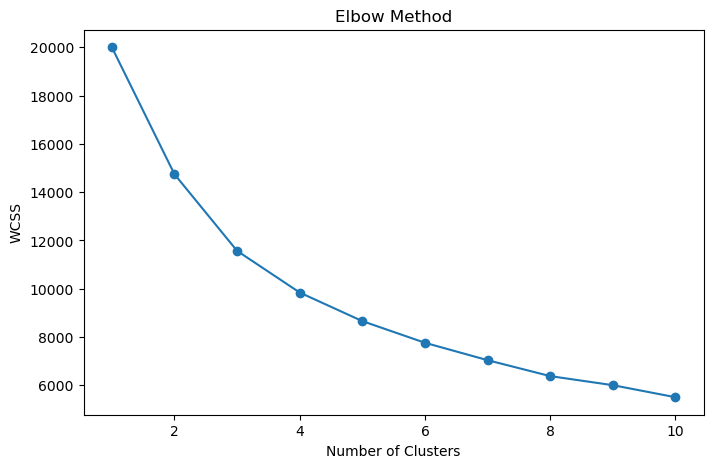

In [134]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculating WCSS for different values of K

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Curve

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

Selecting the Optimal Number of Clusters

The Elbow Method was applied to determine the optimal number of customer segments. The curve showed a significant decrease in WCSS until K = 3, after which the improvement became gradual. Therefore, 3 clusters were selected for customer segmentation.

In [136]:
# Applying K-Means Clustering

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_features)

# Adding cluster labels to the original dataset

df['Cluster'] = clusters

df[['age',
    'purchase_amount',
    'previous_purchases',
    'Cluster']].head()

,age,purchase_amount,previous_purchases,Cluster
0,22,68.0,36.0,2
1,51,84.0,20.0,1
2,18,50.0,18.0,2
3,22,75.0,25.0,2
4,40,80.0,17.0,2


In [138]:
clusters = kmeans.fit_predict(scaled_features)

In [140]:
df['Cluster'] = clusters

In [142]:
df['Cluster'].value_counts()

Cluster
2    2148
1    2082
0     770
Name: count, dtype: int64

## Cluster Profiling

After creating customer segments, the average values of key customer attributes are calculated for each cluster. This helps understand the characteristics of each customer group and supports business decision-making.

In [144]:
# Calculating average characteristics of each customer segment

cluster_summary = df.groupby('Cluster')[[
    'age',
    'purchase_amount',
    'review_rating',
    'previous_purchases'
]].mean().round(2)

cluster_summary

,age,purchase_amount,review_rating,previous_purchases
Cluster,,,,
0,44.70,849.06,2.92,9.78
1,57.52,81.01,3.71,26.05
2,31.08,79.96,3.77,23.55


## Cluster Interpretation

### Cluster 0 – High-Spending Occasional Customers

- Highest average purchase amount
- Lower number of previous purchases
- Lowest average review rating

**Business Recommendation:**
Improve customer satisfaction through personalized follow-ups and loyalty programs to encourage repeat purchases.

---

### Cluster 1 – Loyal Repeat Customers

- Highest number of previous purchases
- Good customer ratings
- Lower average purchase amount

**Business Recommendation:**
Retain these customers using loyalty rewards, exclusive discounts, and subscription benefits.

---

### Cluster 2 – Young Engaged Customers

- Youngest customer group
- Good review ratings
- Frequent purchases
- Lower purchase amount

**Business Recommendation:**
Increase average spending through cross-selling, upselling, and personalized product recommendations.